### Markov Chain Monte Carlo for uniform distribution on a poset's ideals


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

In [14]:
# adjency list
a = 10
b = 20
graph = []
graph.append([i for i in range(1,a+1)])
for i in range(a):
    graph.append([])
for j in range(b):
    graph.append([0])


In [15]:
G = nx.DiGraph()
n = len(graph)

In [16]:

reversed_graph = [[] for i in range(n)]

for i, neighbors in enumerate(graph):
    for j in neighbors:
        G.add_edge(i,j)
        reversed_graph[j].append(i)


nodes = list(G.nodes())

In [17]:
pos = nx.spring_layout(G)
pos = {}

for i in range(1, a+1):
    pos[i] = (i, 0)
pos[0] = (a/2 + 0.5, 1)
for k, i in enumerate(range(a+1, a+b+1)):
    pos[i] = (k + 1, 2)

# pos = {}
# for i in range(a):
#     pos[i] = (0, n - 1 - i)
# for i in range(a):
#     pos[a + i] = (5, n - 1 - i)

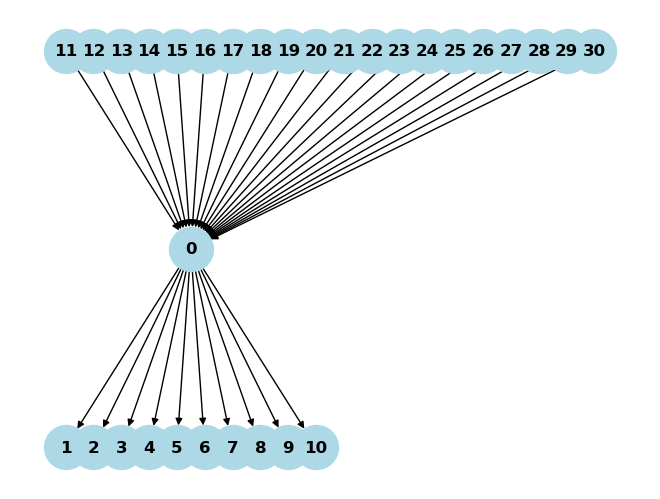

In [18]:
nx.draw(G, pos,with_labels=True,node_color="lightblue",node_size=1000,font_weight="bold")
plt.show()

In [ ]:
# A is the ideal, B is G \ A
A = np.array([False] * n, dtype=bool)
out_degree_A = [0] * n # out degree for subgraph induced by A
in_degree_B = [len(neigh) for neigh in reversed_graph] # in degree for subgraph induced by B

# p[v] will store the proportion of ideals that contain s
p = np.zeros(n)

N = 1000000 # number of iterations for the Metropolis Hastings algorithm

last_enter = [0] * n # last time the node was selected and put in A

In [20]:
for i in range(N):
    k = random.randrange(0,n)

    if not(A[k]) and in_degree_B[k] == 0: # in B and in degree in B is 0 
        A[k] = True # put in A

        last_enter[k] = i
        
        for v in graph[k]:
            in_degree_B[v] -= 1
        for v in reversed_graph[k]:
            out_degree_A[v] += 1

    elif A[k] and out_degree_A[k] == 0: # in A and out degree in A is 0
        A[k] = False # put in B

        p[k] += i - last_enter[k]

        for v in graph[k]:
            in_degree_B[v] += 1
        for v in reversed_graph[k]:
            out_degree_A[v] -= 1  

for k in range(n):
    if A[k]:
        p[k] += N - last_enter[k]

p/=N

In [ ]:
p # p[v] is the proportion of ideals that contain v

array([0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.496025,
       0.501924, 0.503263, 0.498879, 0.499783, 0.502814, 0.496199,
       0.494319, 0.500322, 0.504256, 0.499691, 0.501395, 0.50136 ,
       0.498539, 0.502947, 0.504986, 0.499735, 0.499322, 0.499108,
       0.499191])